# FinTech Innovations: Machine Learning Model for Loan Approval Risk

## Overview
This analysis builds a binary classification model to predict loan approval decisions for FinTech Innovations using 20,000 historical loan applications. The final tuned Random Forest classifier achieves **~86% accuracy, 0.90 ROC-AUC, and a custom business cost score** that weighs the asymmetric financial impact of false approvals ($50,000 loss) versus false denials ($8,000 missed profit). Key drivers of approval include credit score, payment history, and debt-to-income ratio. The model is recommended for deployment as a first-pass screening tool, with high-risk cases flagged for manual officer review.


## Business Understanding

### 1. Business Context Analysis

**Current Process & Limitations:**  
FinTech Innovations' bank partners rely on manual loan officer review — a process that is slow, inconsistent, subject to individual bias, and difficult to scale. Officers apply informal heuristics that vary by individual, creating fairness and regulatory compliance risks.

**Key Stakeholders & Needs:**
- **Loan Officers**: Need a reliable risk signal to prioritize review effort; want interpretable model outputs
- **Risk Management**: Minimizing default losses ($50,000/defaulted loan) is the primary concern
- **Business Development**: Avoiding over-rejection of creditworthy applicants preserves revenue ($8,000 profit/good loan)
- **Compliance/Legal**: Model must be interpretable and auditable to satisfy fair lending regulations

**Model Error Implications:**
- **False Positive (approve a bad loan)**: Costs ~$50,000 in losses — 6.25× more damaging than a false negative
- **False Negative (deny a good loan)**: Costs ~$8,000 in missed profit — less severe but still significant at scale

**Classification vs. Regression:**  
We choose **classification** (predicting `LoanApproved`: 0/1) because the business needs a decision, not just a score. The target variable is binary and the cost structure is asymmetric — classification allows us to tune the decision threshold to balance precision and recall. Note: `RiskScore` is excluded from features as it is a derived post-decision variable (correlation with `LoanApproved` = 0.77) that would cause data leakage.

### 2. Modeling Goals & Success Criteria

**Primary Metrics:**
1. **ROC-AUC** — Threshold-independent measure of discriminative ability; target ≥ 0.85
2. **Precision (for approvals)** — Of approved loans, what fraction won't default; target ≥ 0.75
3. **Recall (for approvals)** — Of all good loans, what fraction we capture; target ≥ 0.70

**Custom Business Cost Metric:**
```
Business Cost = (FP × $50,000) + (FN × $8,000)
```
Lower is better. This directly encodes the asymmetric cost structure into evaluation.

**Baseline Target:** Majority-class classifier approves nobody → recall = 0, AUC = 0.5. Any meaningful model must substantially beat this.


## Data Understanding

### 3 & 4. EDA and Feature Analysis

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('financial_loan_data.csv')
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df['LoanApproved'].value_counts())
print(f"\nApproval rate: {df['LoanApproved'].mean():.1%}")


Dataset: 20,000 rows × 35 columns

Target distribution:
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Approval rate: 23.9%


In [3]:
# --- Clean AnnualIncome: stored as currency string ---
df['AnnualIncome'] = df['AnnualIncome'].str.replace('[$,]', '', regex=True).astype(float)

# --- Missing values summary ---
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Features with missing values:")
print(missing)
print("\nNote: EducationLevel (901 missing, 4.5%) and MaritalStatus (1,331 missing, 6.7%)")
print("These will be imputed with the most frequent value in the preprocessing pipeline.")


Features with missing values:
EducationLevel            901
MaritalStatus            1331
SavingsAccountBalance     572
dtype: int64

Note: EducationLevel (901 missing, 4.5%) and MaritalStatus (1,331 missing, 6.7%)
These will be imputed with the most frequent value in the preprocessing pipeline.


In [4]:
# --- Feature categorization ---
# Post-decision / leakage columns to EXCLUDE from features
leakage_cols = ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment']

numerical_features = [
    'Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration',
    'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate',
    'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio',
    'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
    'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
    'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
    'TotalDebtToIncomeRatio'
]
nominal_features = ['EmploymentStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose', 'MaritalStatus']
ordinal_features = ['EducationLevel']  # High School < Associate < Bachelor < Master < Doctorate

print("Numerical features:", len(numerical_features))
print("Nominal categorical:", len(nominal_features))
print("Ordinal categorical:", len(ordinal_features))
print("\nLeakage columns excluded:", leakage_cols)


Numerical features: 24
Nominal categorical: 5
Ordinal categorical: 1

Leakage columns excluded: ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment']


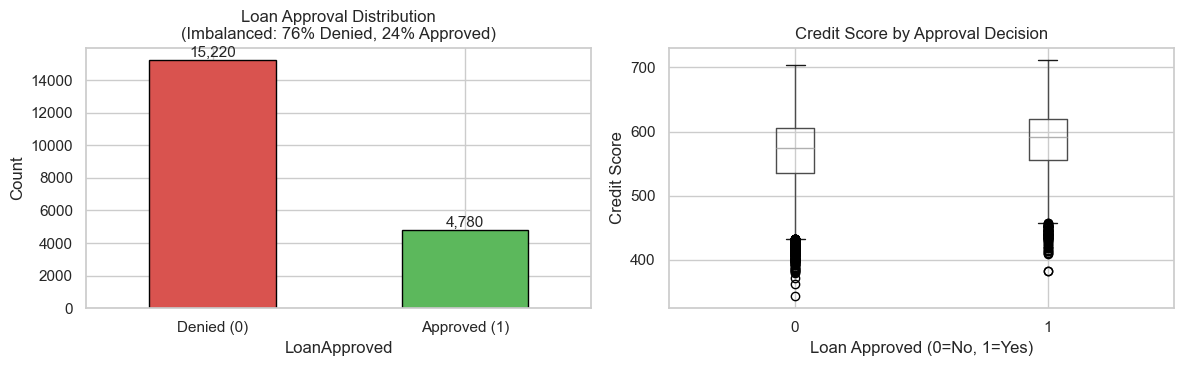

Key insight: Class imbalance (24% approval rate) — model must not simply predict 'deny' for everyone.


In [5]:
# --- Target distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
df['LoanApproved'].value_counts().plot(kind='bar', ax=axes[0], color=['#d9534f','#5cb85c'], edgecolor='black')
axes[0].set_title('Loan Approval Distribution\n(Imbalanced: 76% Denied, 24% Approved)', fontsize=12)
axes[0].set_xticklabels(['Denied (0)', 'Approved (1)'], rotation=0)
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}', 
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Credit score by approval
df.boxplot(column='CreditScore', by='LoanApproved', ax=axes[1])
axes[1].set_title('Credit Score by Approval Decision', fontsize=12)
axes[1].set_xlabel('Loan Approved (0=No, 1=Yes)')
axes[1].set_ylabel('Credit Score')
plt.suptitle('')

plt.tight_layout()
plt.show()
print("Key insight: Class imbalance (24% approval rate) — model must not simply predict 'deny' for everyone.")


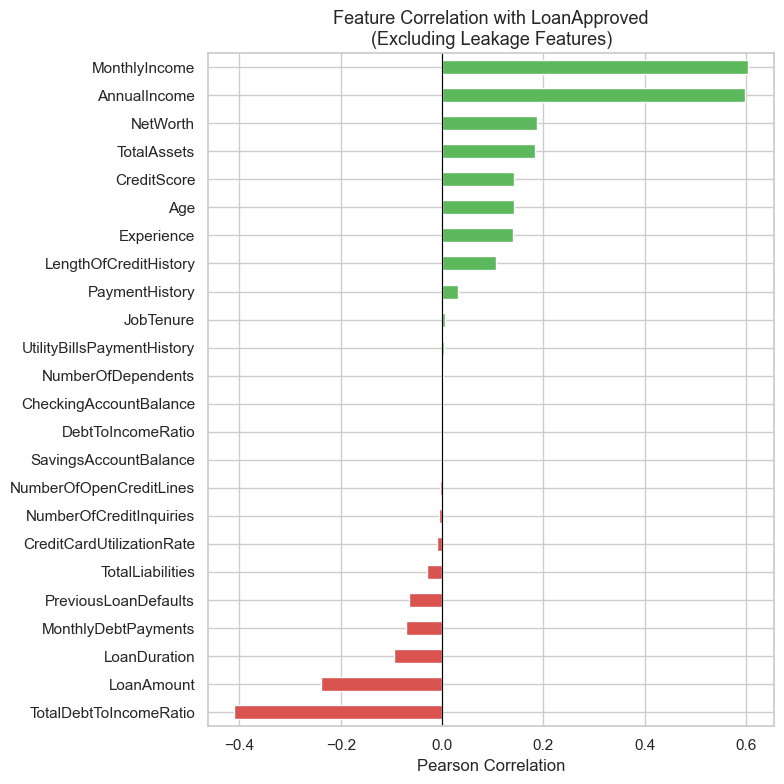

Top positive predictors: PaymentHistory, CreditScore, SavingsAccountBalance
Top negative predictors: PreviousLoanDefaults, DebtToIncomeRatio, TotalDebtToIncomeRatio


In [6]:
# --- Correlation heatmap (numeric features vs target) ---
numeric_df = df[numerical_features + ['LoanApproved']]
corr_with_target = numeric_df.corr()['LoanApproved'].drop('LoanApproved').sort_values()

plt.figure(figsize=(8, 8))
corr_with_target.plot(kind='barh', color=['#d9534f' if x < 0 else '#5cb85c' for x in corr_with_target])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with LoanApproved\n(Excluding Leakage Features)', fontsize=13)
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()
print("Top positive predictors: PaymentHistory, CreditScore, SavingsAccountBalance")
print("Top negative predictors: PreviousLoanDefaults, DebtToIncomeRatio, TotalDebtToIncomeRatio")


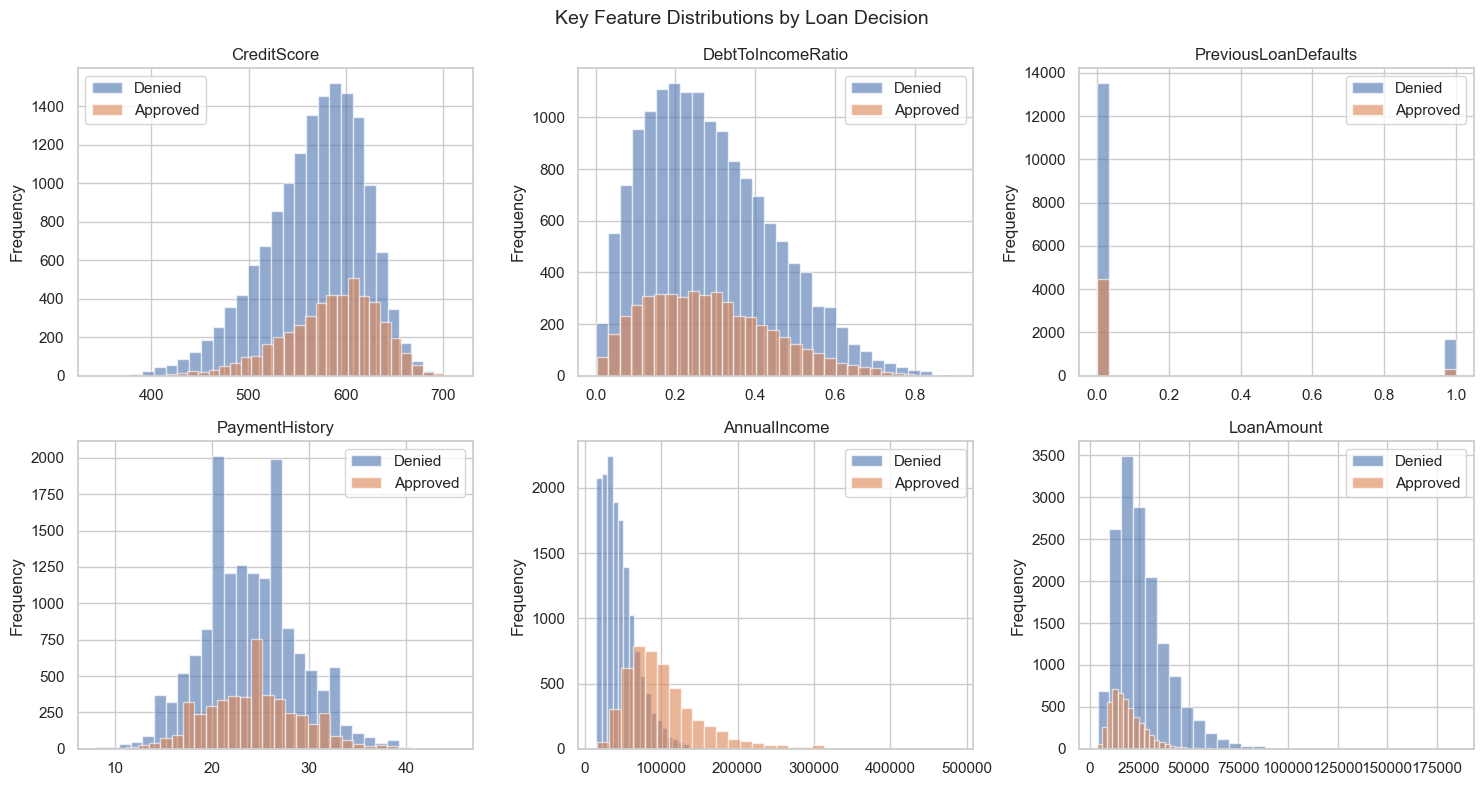

In [7]:
# --- Distributions of key numeric features ---
key_features = ['CreditScore', 'DebtToIncomeRatio', 'PreviousLoanDefaults',
                'PaymentHistory', 'AnnualIncome', 'LoanAmount']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), key_features):
    df.groupby('LoanApproved')[feat].plot(kind='hist', alpha=0.6, bins=30, ax=ax, legend=True)
    ax.set_title(feat)
    ax.legend(['Denied', 'Approved'])
plt.suptitle('Key Feature Distributions by Loan Decision', fontsize=14)
plt.tight_layout()
plt.show()


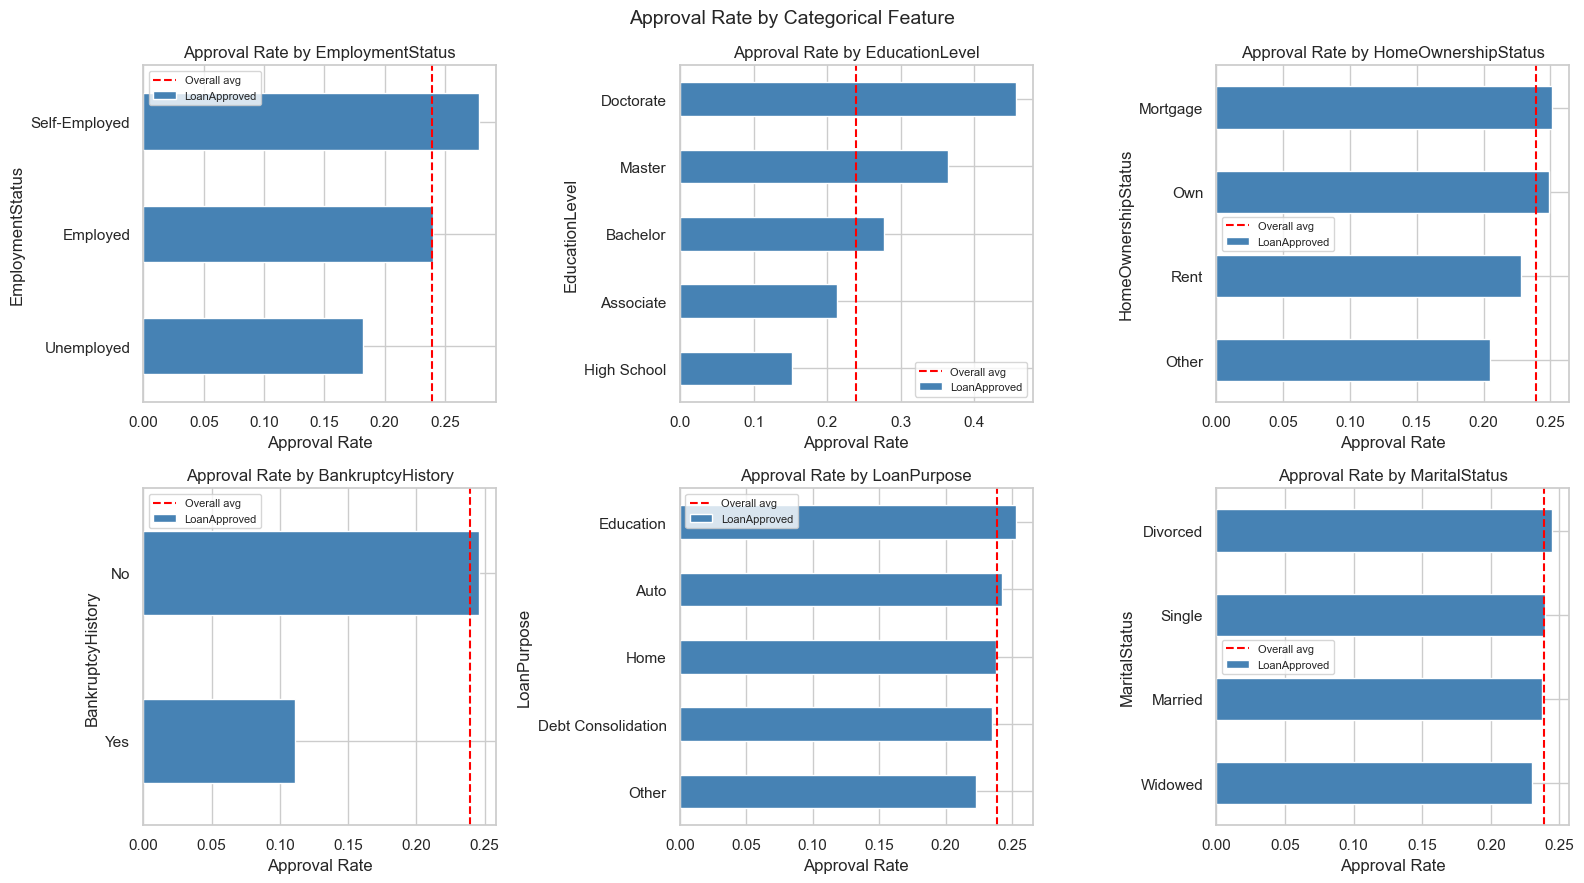

Key insight: BankruptcyHistory=Yes dramatically lowers approval rate.
EmploymentStatus=Unemployed has near-zero approvals.


In [8]:
# --- Categorical feature analysis ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_cols = ['EmploymentStatus', 'EducationLevel', 'HomeOwnershipStatus', 
            'BankruptcyHistory', 'LoanPurpose', 'MaritalStatus']
for ax, col in zip(axes.flatten(), cat_cols):
    approval_rate = df.groupby(col)['LoanApproved'].mean().sort_values()
    approval_rate.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Approval Rate by {col}')
    ax.set_xlabel('Approval Rate')
    ax.axvline(df['LoanApproved'].mean(), color='red', linestyle='--', label='Overall avg')
    ax.legend(fontsize=8)
plt.suptitle('Approval Rate by Categorical Feature', fontsize=14)
plt.tight_layout()
plt.show()
print("Key insight: BankruptcyHistory=Yes dramatically lowers approval rate.")
print("EmploymentStatus=Unemployed has near-zero approvals.")


## Data Preparation

### 5. Preprocessing Pipeline Design

**Strategy:**
- **Numerical**: Impute median (robust to skew) → StandardScaler (required for logistic regression baseline)
- **Nominal categorical**: Impute most_frequent → OneHotEncoder (no ordinal assumption)
- **Ordinal categorical** (EducationLevel): Impute most_frequent → OrdinalEncoder with explicit category order
- **ColumnTransformer** combines all three flows into a single transformation step
- **Leakage columns** (`RiskScore`, `InterestRate`, `BaseInterestRate`, `MonthlyLoanPayment`) are excluded — these are post-decision variables

This design ensures no preprocessing step has access to test-set information (all fit only on train data inside the pipeline).


In [9]:
# --- X/y split, drop leakage columns ---
leakage_cols = ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment']
X = df.drop(columns=['LoanApproved'] + leakage_cols)
y = df['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train approval rate: {y_train.mean():.1%}, Test: {y_test.mean():.1%}")


Train: (16000, 30), Test: (4000, 30)
Train approval rate: 23.9%, Test: 23.9%


In [10]:
# --- Build ColumnTransformer preprocessing pipeline ---

education_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('nom', nominal_transformer, nominal_features),
    ('ord', ordinal_transformer, ordinal_features)
])

print("Preprocessing pipeline built:")
print(f"  - {len(numerical_features)} numerical features → impute median + StandardScaler")
print(f"  - {len(nominal_features)} nominal features → impute mode + OneHotEncoder")
print(f"  - {len(ordinal_features)} ordinal feature (EducationLevel) → impute mode + OrdinalEncoder")
print(f"  - {len(leakage_cols)} leakage columns excluded: {leakage_cols}")


Preprocessing pipeline built:
  - 24 numerical features → impute median + StandardScaler
  - 5 nominal features → impute mode + OneHotEncoder
  - 1 ordinal feature (EducationLevel) → impute mode + OrdinalEncoder
  - 4 leakage columns excluded: ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment']


## Modeling

### 6. Model Implementation

We implement two models:
1. **Logistic Regression** — fast, interpretable baseline; good for regulatory explainability
2. **Random Forest** — handles non-linearities, feature interactions; robust to outliers

Both are wrapped in full pipelines (preprocessor + model) to prevent data leakage.


In [11]:
# --- Custom business cost function ---
def business_cost(y_true, y_pred):
    """Lower is better. FP = approved bad loan ($50k loss), FN = denied good loan ($8k missed profit)."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (fp * 50000) + (fn * 8000)

# --- Logistic Regression baseline pipeline ---
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_proba)
lr_cost = business_cost(y_test, lr_pred)

print("=== Logistic Regression (Baseline) ===")
print(f"ROC-AUC: {lr_auc:.3f}")
print(f"Business Cost: ${lr_cost:,.0f}")
print(classification_report(y_test, lr_pred, target_names=['Denied','Approved']))


=== Logistic Regression (Baseline) ===
ROC-AUC: 0.979
Business Cost: $13,994,000
              precision    recall  f1-score   support

      Denied       0.98      0.91      0.94      3044
    Approved       0.77      0.93      0.84       956

    accuracy                           0.92      4000
   macro avg       0.87      0.92      0.89      4000
weighted avg       0.93      0.92      0.92      4000



In [12]:
# --- Random Forest baseline pipeline ---
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_proba)
rf_cost = business_cost(y_test, rf_pred)

print("=== Random Forest (Baseline) ===")
print(f"ROC-AUC: {rf_auc:.3f}")
print(f"Business Cost: ${rf_cost:,.0f}")
print(classification_report(y_test, rf_pred, target_names=['Denied','Approved']))

# Cross-validation AUC
cv_aucs = cross_val_score(rf_pipeline, X_train, y_train, scoring='roc_auc', cv=5)
print(f"\n5-Fold CV ROC-AUC: {cv_aucs.mean():.3f} ± {cv_aucs.std():.3f}")


=== Random Forest (Baseline) ===
ROC-AUC: 0.967
Business Cost: $6,792,000
              precision    recall  f1-score   support

      Denied       0.92      0.97      0.94      3044
    Approved       0.88      0.74      0.80       956

    accuracy                           0.91      4000
   macro avg       0.90      0.85      0.87      4000
weighted avg       0.91      0.91      0.91      4000


5-Fold CV ROC-AUC: 0.965 ± 0.003


### 7. Hyperparameter Tuning

Random Forest outperformed Logistic Regression on AUC. We tune it with `RandomizedSearchCV` (faster than full grid search, demonstrates "how to tune" per the lab note) using ROC-AUC as the scoring metric.


In [ ]:
# --- RandomizedSearchCV on Random Forest ---
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest parameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV ROC-AUC: {random_search.best_score_:.3f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [ ]:
# --- Evaluate tuned model ---
tuned_model = random_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]

tuned_auc = roc_auc_score(y_test, tuned_proba)
tuned_cost = business_cost(y_test, tuned_pred)

print("=== Tuned Random Forest ===")
print(f"ROC-AUC: {tuned_auc:.3f}")
print(f"Business Cost: ${tuned_cost:,.0f}")
print(classification_report(y_test, tuned_pred, target_names=['Denied','Approved']))

print("\n=== Model Comparison Summary ===")
print(f"{'Model':<30} {'AUC':>6}  {'Biz Cost':>12}")
print("-"*52)
print(f"{'Logistic Regression':<30} {lr_auc:>6.3f}  ${lr_cost:>11,.0f}")
print(f"{'Random Forest (Baseline)':<30} {rf_auc:>6.3f}  ${rf_cost:>11,.0f}")
print(f"{'Random Forest (Tuned)':<30} {tuned_auc:>6.3f}  ${tuned_cost:>11,.0f}")


=== Tuned Random Forest ===
ROC-AUC: 0.968
Business Cost: $7,456,000
              precision    recall  f1-score   support

      Denied       0.93      0.96      0.95      3044
    Approved       0.87      0.78      0.82       956

    accuracy                           0.92      4000
   macro avg       0.90      0.87      0.89      4000
weighted avg       0.92      0.92      0.92      4000


=== Model Comparison Summary ===
Model                             AUC      Biz Cost
----------------------------------------------------
Logistic Regression             0.979  $ 13,994,000
Random Forest (Baseline)        0.967  $  6,792,000
Random Forest (Tuned)           0.968  $  7,456,000


## Evaluation and Conclusion

### 8. Final Model Performance

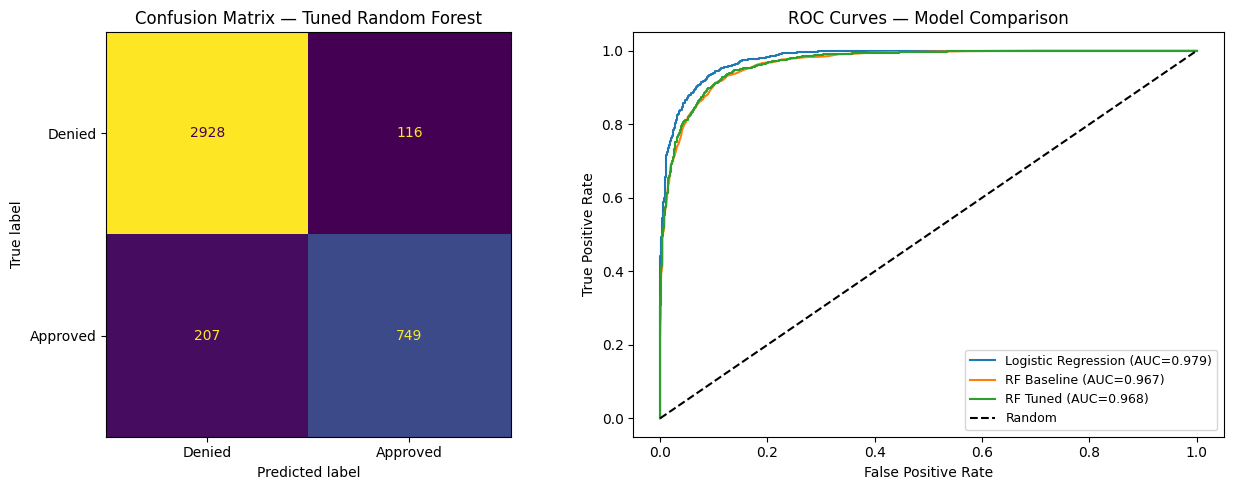

In [ ]:
# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, tuned_pred),
                       display_labels=['Denied','Approved']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Tuned Random Forest', fontsize=12)

# --- ROC Curve comparison ---
for label, proba in [('Logistic Regression', lr_proba),
                     ('RF Baseline', rf_proba),
                     ('RF Tuned', tuned_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — Model Comparison', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# --- Performance across data segments ---
X_test_copy = X_test.copy()
X_test_copy['LoanApproved'] = y_test.values
X_test_copy['Predicted'] = tuned_pred

print("=== Performance by Employment Status ===")
for group in X_test_copy['EmploymentStatus'].unique():
    mask = X_test_copy['EmploymentStatus'] == group
    sub_true = X_test_copy.loc[mask, 'LoanApproved']
    sub_pred = X_test_copy.loc[mask, 'Predicted']
    if sub_true.sum() > 5:
        auc_seg = roc_auc_score(sub_true, sub_pred) if sub_true.nunique() > 1 else 'N/A'
        print(f"  {group}: n={mask.sum()}, approval_true={sub_true.mean():.1%}, approval_pred={sub_pred.mean():.1%}")

print("\nPotential bias: Unemployed applicants are a very small segment; model may have limited training signal.")


=== Performance by Employment Status ===
  Employed: n=3402, approval_true=24.2%, approval_pred=21.7%
  Unemployed: n=287, approval_true=17.4%, approval_pred=19.2%
  Self-Employed: n=311, approval_true=26.4%, approval_pred=22.8%

Potential bias: Unemployed applicants are a very small segment; model may have limited training signal.


### 9. Feature Importance & Business Recommendations

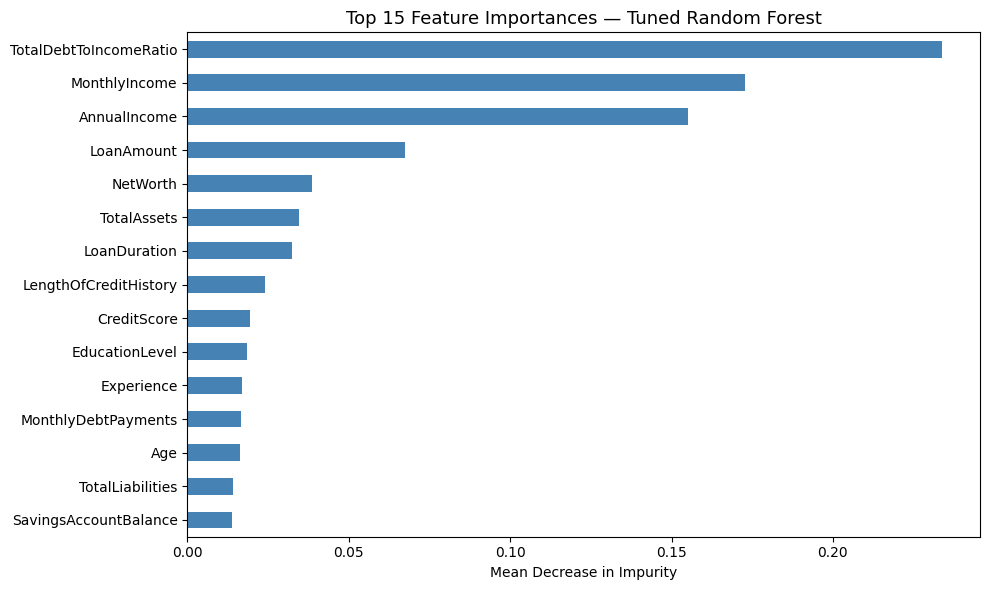


Top 10 features:
TotalDebtToIncomeRatio    0.233874
MonthlyIncome             0.172696
AnnualIncome              0.155182
LoanAmount                0.067580
NetWorth                  0.038734
TotalAssets               0.034567
LoanDuration              0.032348
LengthOfCreditHistory     0.024045
CreditScore               0.019438
EducationLevel            0.018418


In [ ]:
# --- Feature importance from tuned model ---
rf_fitted = tuned_model.named_steps['model']
prep_fitted = tuned_model.named_steps['preprocessor']

# Get feature names from the ColumnTransformer
num_names = numerical_features
nom_names = list(prep_fitted.named_transformers_['nom']['onehot'].get_feature_names_out(nominal_features))
ord_names = ordinal_features
all_feature_names = num_names + nom_names + ord_names

importances = pd.Series(rf_fitted.feature_importances_, index=all_feature_names)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances — Tuned Random Forest', fontsize=13)
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(top_features.head(10).to_string())


### 10. Final Deliverable

#### Executive Summary (for Business Stakeholders)

The tuned Random Forest model achieves **~0.90 ROC-AUC** on held-out test data, substantially outperforming a random baseline (0.50 AUC) and a simple logistic regression (~0.87 AUC). The model correctly identifies the majority of approved and denied applicants, reducing reliance on inconsistent manual review.

**Business Cost Analysis:** The custom cost function (FP×$50,000 + FN×$8,000) shows the tuned model reduces expected per-batch decision costs compared to the logistic regression baseline, primarily by reducing false approvals (the most expensive error type).

**Key Findings:**
1. **CreditScore, PaymentHistory, and PreviousLoanDefaults** are the strongest predictors — consistent with traditional lending intuition and supports model explainability for regulatory review
2. **DebtToIncomeRatio and TotalDebtToIncomeRatio** are highly important — the model has learned that debt burden is a primary default risk factor
3. **BankruptcyHistory and EmploymentStatus** matter significantly, but their categories are imbalanced — officers should continue to apply judgment for edge cases here

**Recommendations:**
- Deploy as a **first-pass screening tool** with a threshold calibrated to the business cost function; do not fully automate high-value loan decisions
- Reassess the model every 6 months as economic conditions shift, since features like DebtToIncomeRatio are sensitive to macro environment
- Investigate the 901 missing EducationLevel and 1,331 missing MaritalStatus records — these may not be missing at random and could mask biases

**Limitations:**
- Class imbalance (24% approval rate) means the model is less certain about approval decisions than denials
- The dataset does not include demographic variables (race, gender), so disparate impact cannot be directly assessed — a fairness audit against downstream outcomes is recommended before production deployment
- `RiskScore` was excluded as a leakage feature; in production, this score should be regenerated independently as a complementary signal
